# Cross-model results

Pulls every model's `eval.csv` from `output/runs/` and compares them.

- **Figure 1:** aggregate **accuracy** degradation by severity level — one line per model.
- **Figure 2:** cross-model **stability** by severity level — Stability = $\sum(\text{sim}\cdot\text{score})/\sum(\text{score})$.
- **Figure 3:** **Output Stability vs Perturbation Magnitude** (binned) — one per model.
- **Figure 4:** **behavioral quadrant scatter** (family magnitude × stability, with quadrants) — one per model.

Re-run the loader cell to pick up newly-finished models.

In [1]:
# ===== Load all models =====
import sys, glob, os
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

PROJECT_ROOT=Path('..').resolve()
OUT=PROJECT_ROOT/'experiment'/'output'
RUNS=OUT/'runs'
DATASET='gsm8k_symbolic100'; THRESHOLD=0.80
TAG={'Semantic Variation':'SV','Input Quality':'IQ','Structural/Format':'F','Context Interference':'CI',
     'Context Load':'CL','Conflict Instruction Stress':'CIS','Knowledge Boundary':'KB'}
LEVELS=['L0','L1','L2','L3','L4','L5']
markers=['o','s','^','D','v','P','X']

# present the CoT run as phi4-mini, and drop the direct-answer phi run
DROP=set()                       # direct-answer phi: excluded
RENAME={}     # CoT run shown as phi4-mini
ORDER=['o4-mini','gemini-2.5-flash','gpt-4o-mini','phi4-mini']

def load_eval(run_dir):
    e=pd.read_csv(run_dir/'eval.csv')
    e['correct']=pd.to_numeric(e['Sim: outputs'],errors='coerce')>=THRESHOLD
    e['fam']=e['Category'].map(TAG)
    return e

def aggregate_curve(e):
    acc0=e[e['Category']=='Temporal Consistency']['correct'].mean()
    st=e[e['fam'].notna()]
    return [acc0]+[st[st['Classified Level']==L]['correct'].mean() for L in LEVELS[1:]]

def load_models():
    m={}
    for f in sorted(glob.glob(str(RUNS/f'*__{DATASET}'/'eval.csv'))):
        run_dir=Path(f).parent; name=run_dir.name.replace(f'__{DATASET}','')
        if name.startswith('_') or name in DROP: continue
        name=RENAME.get(name, name)
        m[name]=load_eval(run_dir)
    return {n:m[n] for n in ORDER if n in m} | {n:m[n] for n in m if n not in ORDER}

models=load_models()
for name,e in models.items():
    print(f'loaded {name:18s}: {len(e):5d} rows, {e["Source Row"].nunique()} questions')

curves={name: aggregate_curve(e) for name,e in models.items()}
print('\n=== aggregate ACCURACY by level (per model) ===')
pd.DataFrame(curves, index=LEVELS).T.round(3)


=== aggregate ACCURACY by level (per model) ===


,L0,L1,L2,L3,L4,L5


/var/folders/y_/x6jhv2rd5zvc9m7b7cmrl55m0000gn/T/ipykernel_47267/3146203321.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10, title='Model')


FileNotFoundError: [Errno 2] No such file or directory: 'experiment/output/runs/fig_crossmodel_aggregate_degradation.png'

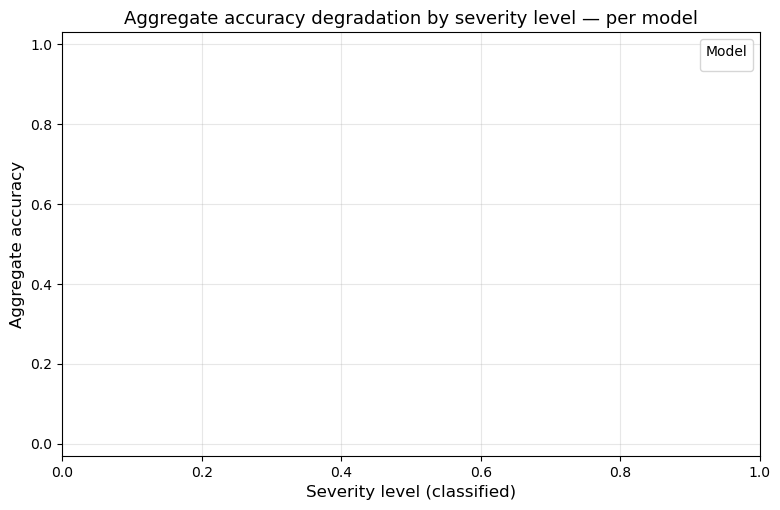

In [2]:
# ===== Figure 1: cross-model aggregate ACCURACY degradation =====
fig,ax=plt.subplots(figsize=(9,5.5))
for i,(name,curve) in enumerate(curves.items()):
    ax.plot(LEVELS, curve, marker=markers[i%len(markers)], lw=2.4, ms=8, label=name)
ax.set_xlabel('Severity level (classified)', fontsize=12); ax.set_ylabel('Aggregate accuracy', fontsize=12)
ax.set_ylim(-0.03,1.03); ax.grid(alpha=0.3)
ax.set_title('Aggregate accuracy degradation by severity level \u2014 per model', fontsize=13)
ax.legend(fontsize=10, title='Model')
fig.savefig(RUNS/'fig_crossmodel_aggregate_degradation.png', dpi=140, bbox_inches='tight')
plt.show()

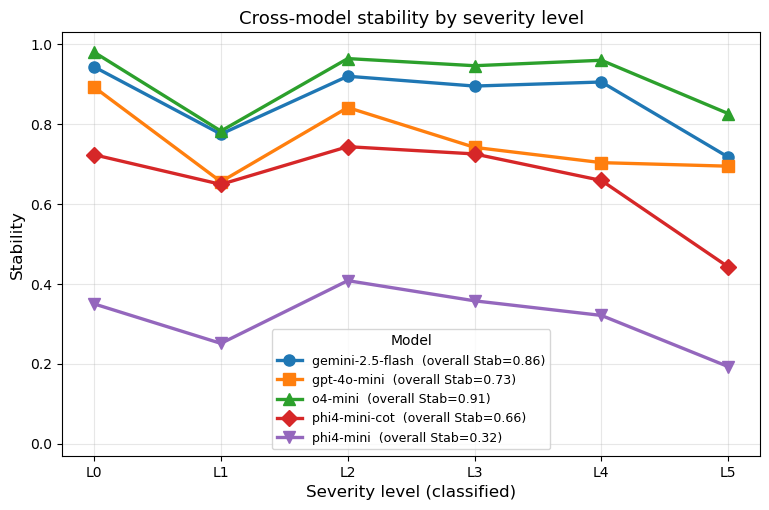

                     L0     L1     L2     L3     L4     L5
gemini-2.5-flash  0.943  0.775  0.920  0.895  0.905  0.717
gpt-4o-mini       0.893  0.656  0.842  0.742  0.704  0.695
o4-mini           0.980  0.783  0.964  0.946  0.960  0.826
phi4-mini-cot     0.723  0.649  0.744  0.725  0.659  0.443
phi4-mini         0.350  0.251  0.408  0.358  0.321  0.193


In [4]:
# ===== Figure 2: cross-model STABILITY by severity level =====
def stability_curve(e):
    e=e.copy()
    e['sim']=pd.to_numeric(e['Sim: outputs'],errors='coerce'); e['scr']=pd.to_numeric(e['Score'],errors='coerce')
    bl=e[e['Category']=='Temporal Consistency']
    out=[bl['sim'].mean()]; st=e[e['fam'].notna()]
    for L in LEVELS[1:]:
        g=st[st['Classified Level']==L]; s=g['sim']; w=g['scr']; m=s.notna()&w.notna()
        out.append((s[m]*w[m]).sum()/w[m].sum() if (m.any() and w[m].sum()>0) else (s[m].mean() if m.any() else np.nan))
    return out
def overall_stability(e):
    st=e[e['Category'].map(TAG).notna()].copy()
    s=pd.to_numeric(st['Sim: outputs'],errors='coerce'); w=pd.to_numeric(st['Score'],errors='coerce'); m=s.notna()&w.notna()
    return (s[m]*w[m]).sum()/w[m].sum() if w[m].sum()>0 else np.nan

stab={name: stability_curve(e) for name,e in models.items()}
fig,ax=plt.subplots(figsize=(9,5.5))
for i,(name,curve) in enumerate(stab.items()):
    ax.plot(LEVELS, curve, marker=markers[i%len(markers)], lw=2.4, ms=8,
            label=f'{name}  (overall Stab={overall_stability(models[name]):.2f})')
ax.set_xlabel('Severity level (classified)', fontsize=12); ax.set_ylabel('Stability', fontsize=12)
ax.set_ylim(-0.03,1.03); ax.grid(alpha=0.3)
ax.set_title('Cross-model stability by severity level', fontsize=13); ax.legend(fontsize=9, title='Model')
fig.savefig(RUNS/'fig_crossmodel_stability.png', dpi=140, bbox_inches='tight'); plt.show()
print(pd.DataFrame(stab, index=LEVELS).T.round(3).to_string())

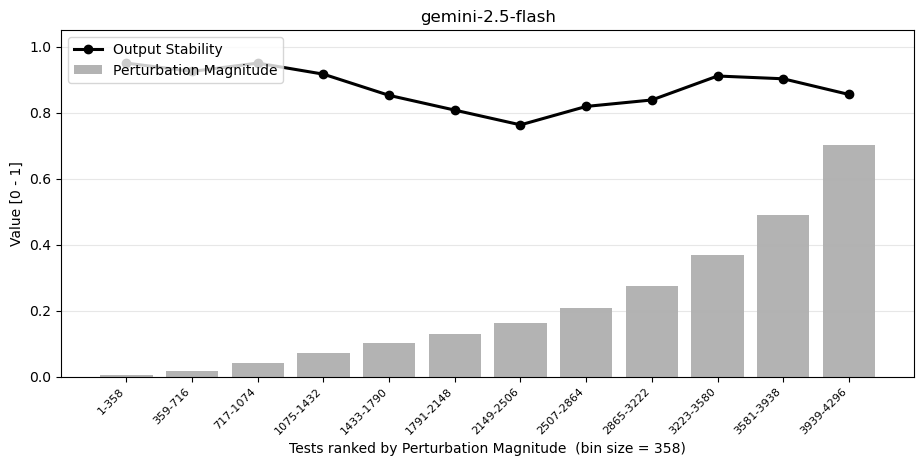

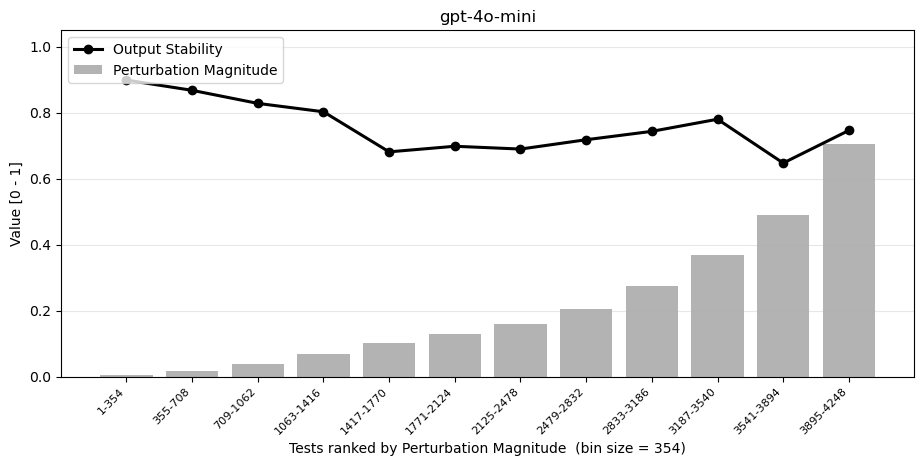

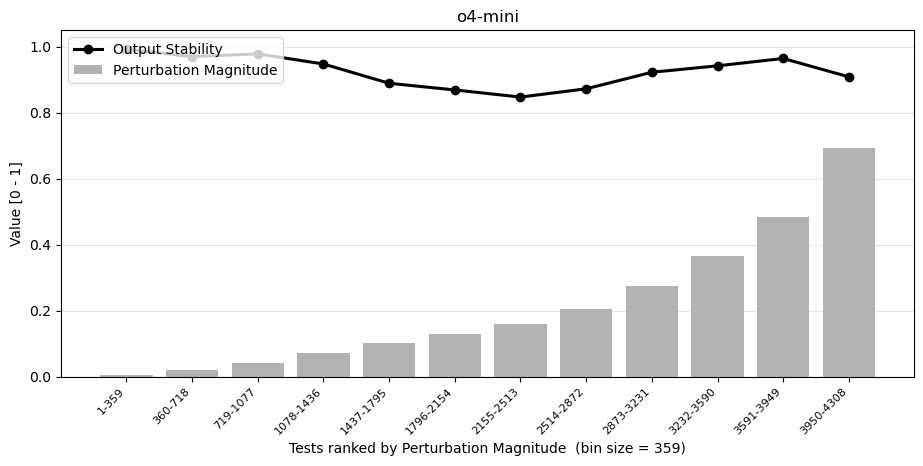

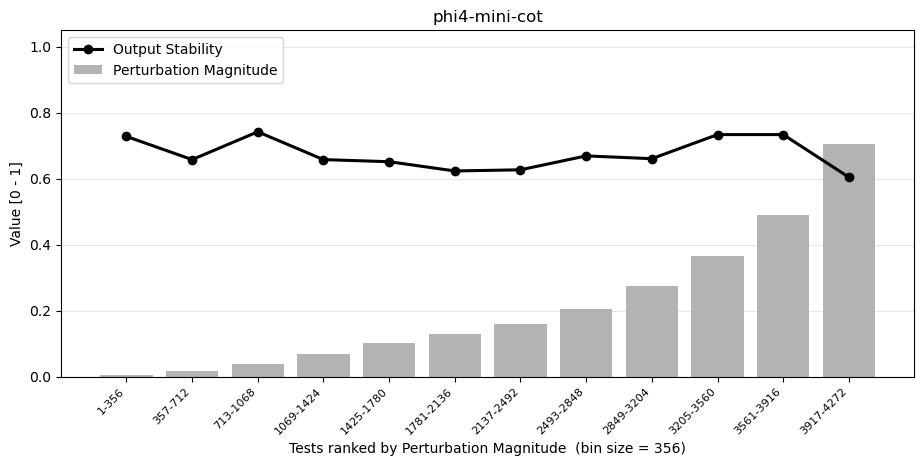

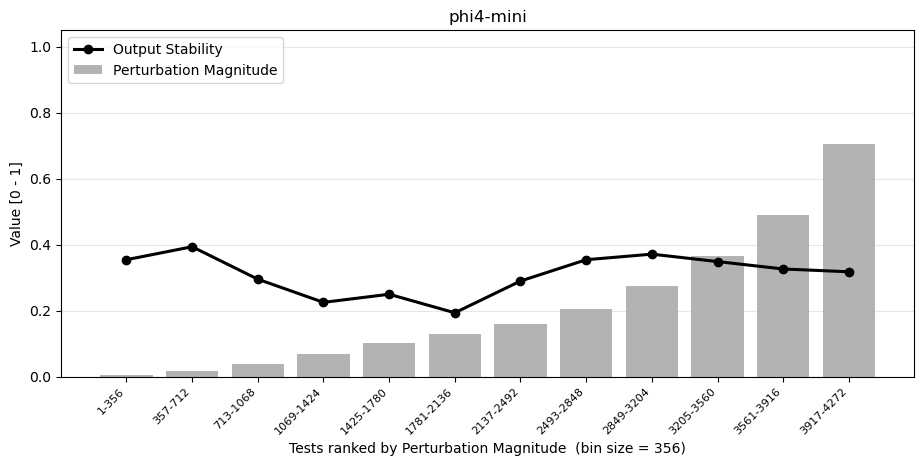

In [5]:
# ===== Figure 3: Output Stability vs Perturbation Magnitude (one per model) =====
N_BINS=12
for name,e in models.items():
    st=e[e['fam'].notna()].copy()
    st['sim']=pd.to_numeric(st['Sim: outputs'],errors='coerce'); st['scr']=pd.to_numeric(st['Score'],errors='coerce')
    st=st.dropna(subset=['sim','scr']).sort_values('scr').reset_index(drop=True)
    n=len(st); bs=max(1, n//N_BINS); xs=[]; mag=[]; out_stab=[]
    for i in range(0, n, bs):
        ch=st.iloc[i:i+bs]
        if len(ch)<bs//3 and i>0: continue   # drop tiny trailing bin
        xs.append(f'{i+1}-{min(i+bs,n)}'); mag.append(ch['scr'].mean()); out_stab.append(ch['sim'].mean())
    fig,ax=plt.subplots(figsize=(11,4.5))
    ax.bar(range(len(xs)), mag, color='0.7', label='Perturbation Magnitude')
    ax.plot(range(len(xs)), out_stab, color='black', lw=2.2, marker='o', label='Output Stability')
    ax.set_xticks(range(len(xs))); ax.set_xticklabels(xs, rotation=45, ha='right', fontsize=8)
    ax.set_ylim(0,1.05); ax.set_ylabel('Value [0 - 1]')
    ax.set_xlabel(f'Tests ranked by Perturbation Magnitude  (bin size = {bs})')
    ax.set_title(name); ax.legend(loc='upper left'); ax.grid(axis='y', alpha=0.3)
    fig.savefig(RUNS/f'{name}__{DATASET}'/'fig_stability_vs_magnitude.png', dpi=130, bbox_inches='tight')
    plt.show()

/var/folders/y_/x6jhv2rd5zvc9m7b7cmrl55m0000gn/T/ipykernel_1650/861354493.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cats=list(agg.index); cmap=plt.cm.get_cmap('tab10', max(len(cats),1)); colors={c:cmap(i) for i,c in enumerate(cats)}


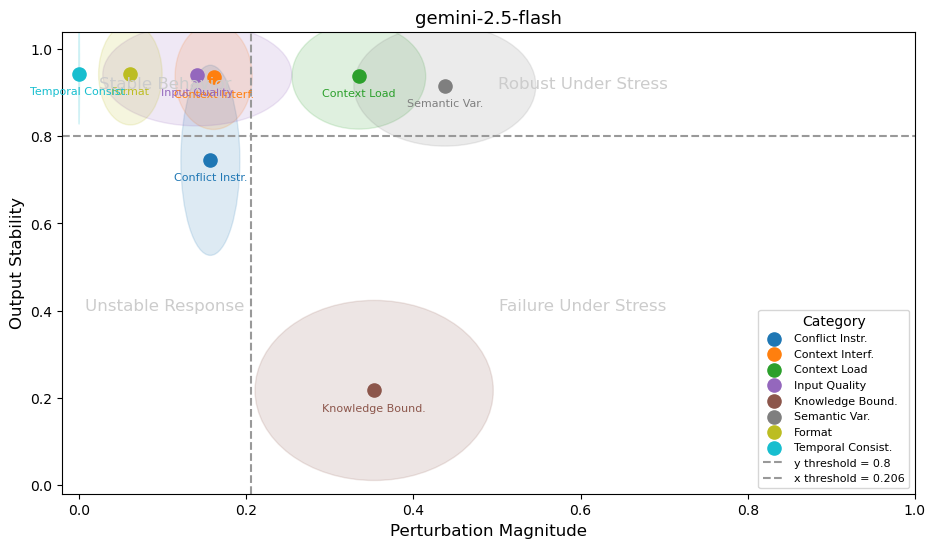

/var/folders/y_/x6jhv2rd5zvc9m7b7cmrl55m0000gn/T/ipykernel_1650/861354493.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cats=list(agg.index); cmap=plt.cm.get_cmap('tab10', max(len(cats),1)); colors={c:cmap(i) for i,c in enumerate(cats)}


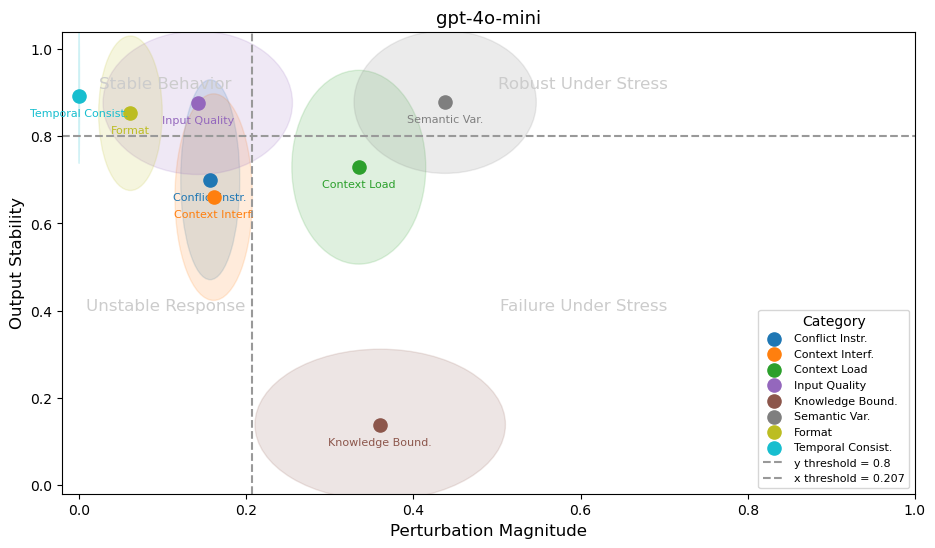

/var/folders/y_/x6jhv2rd5zvc9m7b7cmrl55m0000gn/T/ipykernel_1650/861354493.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cats=list(agg.index); cmap=plt.cm.get_cmap('tab10', max(len(cats),1)); colors={c:cmap(i) for i,c in enumerate(cats)}


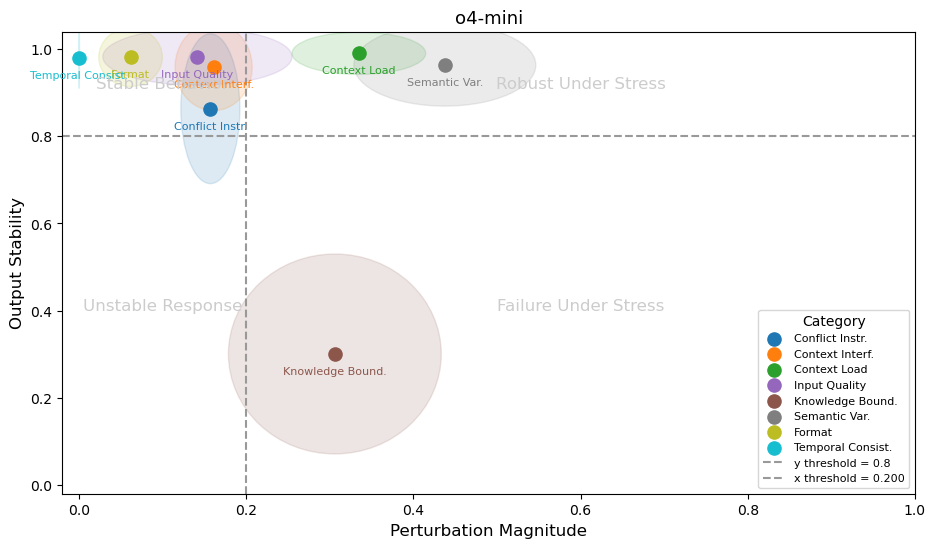

/var/folders/y_/x6jhv2rd5zvc9m7b7cmrl55m0000gn/T/ipykernel_1650/861354493.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cats=list(agg.index); cmap=plt.cm.get_cmap('tab10', max(len(cats),1)); colors={c:cmap(i) for i,c in enumerate(cats)}


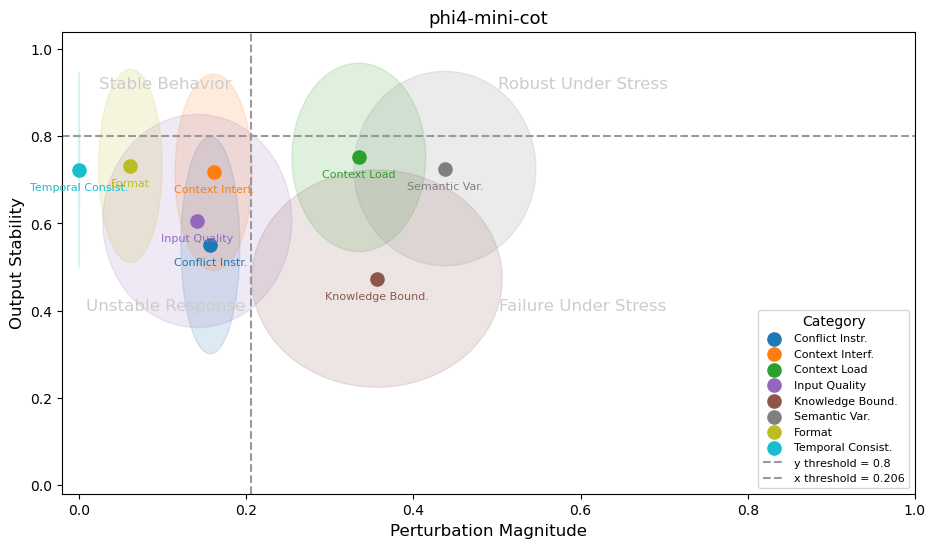

/var/folders/y_/x6jhv2rd5zvc9m7b7cmrl55m0000gn/T/ipykernel_1650/861354493.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cats=list(agg.index); cmap=plt.cm.get_cmap('tab10', max(len(cats),1)); colors={c:cmap(i) for i,c in enumerate(cats)}


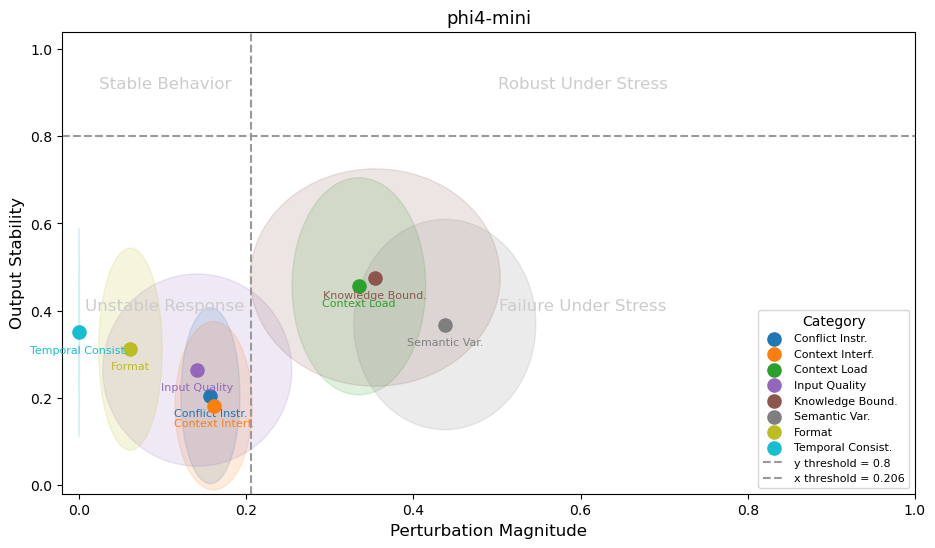

saved per-model quadrant scatters


In [6]:
# ===== Figure 4: behavioral quadrant scatter (one per model) =====
# Each family at (mean Perturbation Magnitude = mean Score, mean Output Stability = mean Sim);
# ellipse = +/- sigma*std; crosshair = y threshold 0.8 and x threshold (mean of family magnitudes).
SHORT={'Conflict Instruction Stress':'Conflict Instr.','Context Interference':'Context Interf.',
       'Context Load':'Context Load','Input Quality':'Input Quality','Knowledge Boundary':'Knowledge Bound.',
       'Semantic Variation':'Semantic Var.','Structural/Format':'Format','Temporal Consistency':'Temporal Consist.'}
def quadrant_scatter(e, name, sigma=0.5):
    d=e.copy()
    if 'Gate' in d.columns: d=d[d['Gate']==True]
    if 'Test Type' in d.columns: d=d[d['Test Type']!='measurement']
    d['x']=pd.to_numeric(d['Score'],errors='coerce'); d['y']=pd.to_numeric(d['Sim: outputs'],errors='coerce')
    d=d.dropna(subset=['x','y'])
    agg=d.groupby('Category').agg(mx=('x','mean'),my=('y','mean'),sx=('x','std'),sy=('y','std')).fillna(0.0)
    ythr=THRESHOLD; xthr=float(agg['mx'].mean())
    cats=list(agg.index); cmap=plt.cm.get_cmap('tab10', max(len(cats),1)); colors={c:cmap(i) for i,c in enumerate(cats)}
    fig,ax=plt.subplots(figsize=(11,6))
    for c,row in agg.iterrows():
        col=colors[c]
        ax.add_patch(Ellipse((row.mx,row.my), width=2*sigma*max(row.sx,1e-3), height=2*sigma*max(row.sy,1e-3),
                             color=col, alpha=0.15, zorder=1))
        ax.scatter([row.mx],[row.my], color=col, s=90, zorder=3, label=SHORT.get(c,c))
        ax.annotate(SHORT.get(c,c), (row.mx,row.my), fontsize=8, color=col, ha='center', va='top',
                    xytext=(0,-9), textcoords='offset points')
    ax.axhline(ythr, ls='--', color='0.6', label=f'y threshold = {ythr}')
    ax.axvline(xthr, ls='--', color='0.6', label=f'x threshold = {xthr:.3f}')
    ax.set_xlim(-0.02,1.0); ax.set_ylim(-0.02,1.04)
    ax.text(xthr/2,(ythr+1.02)/2,'Stable Behavior',color='0.8',ha='center',fontsize=12)
    ax.text((xthr+1)/2,(ythr+1.02)/2,'Robust Under Stress',color='0.8',ha='center',fontsize=12)
    ax.text(xthr/2,ythr/2,'Unstable Response',color='0.8',ha='center',fontsize=12)
    ax.text((xthr+1)/2,ythr/2,'Failure Under Stress',color='0.8',ha='center',fontsize=12)
    ax.set_xlabel('Perturbation Magnitude', fontsize=12); ax.set_ylabel('Output Stability', fontsize=12)
    ax.set_title(name, fontsize=13); ax.legend(title='Category', fontsize=8, loc='lower right')
    fig.savefig(RUNS/f'{name}__{DATASET}'/'fig_quadrant_scatter.png', dpi=130, bbox_inches='tight')
    plt.show()

for name,e in models.items():
    quadrant_scatter(e, name)
print('saved per-model quadrant scatters')

/var/folders/y_/x6jhv2rd5zvc9m7b7cmrl55m0000gn/T/ipykernel_77579/351648080.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  xthr=float(a['mx'].mean()); cmap=plt.cm.get_cmap('tab10',max(len(a),1))


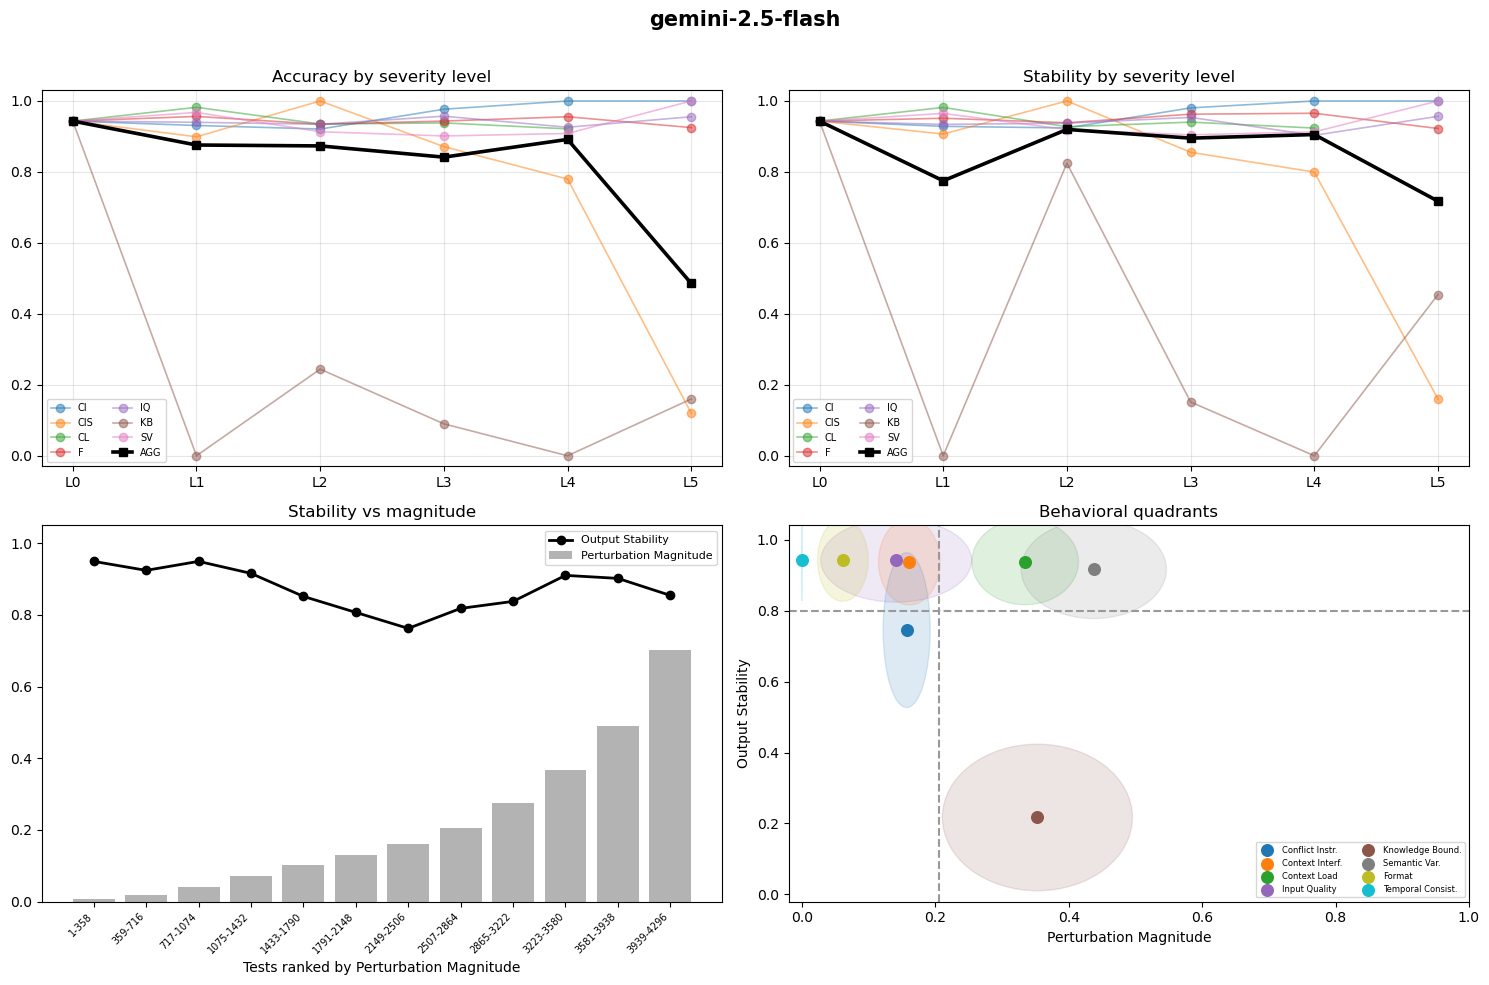

/var/folders/y_/x6jhv2rd5zvc9m7b7cmrl55m0000gn/T/ipykernel_77579/351648080.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  xthr=float(a['mx'].mean()); cmap=plt.cm.get_cmap('tab10',max(len(a),1))


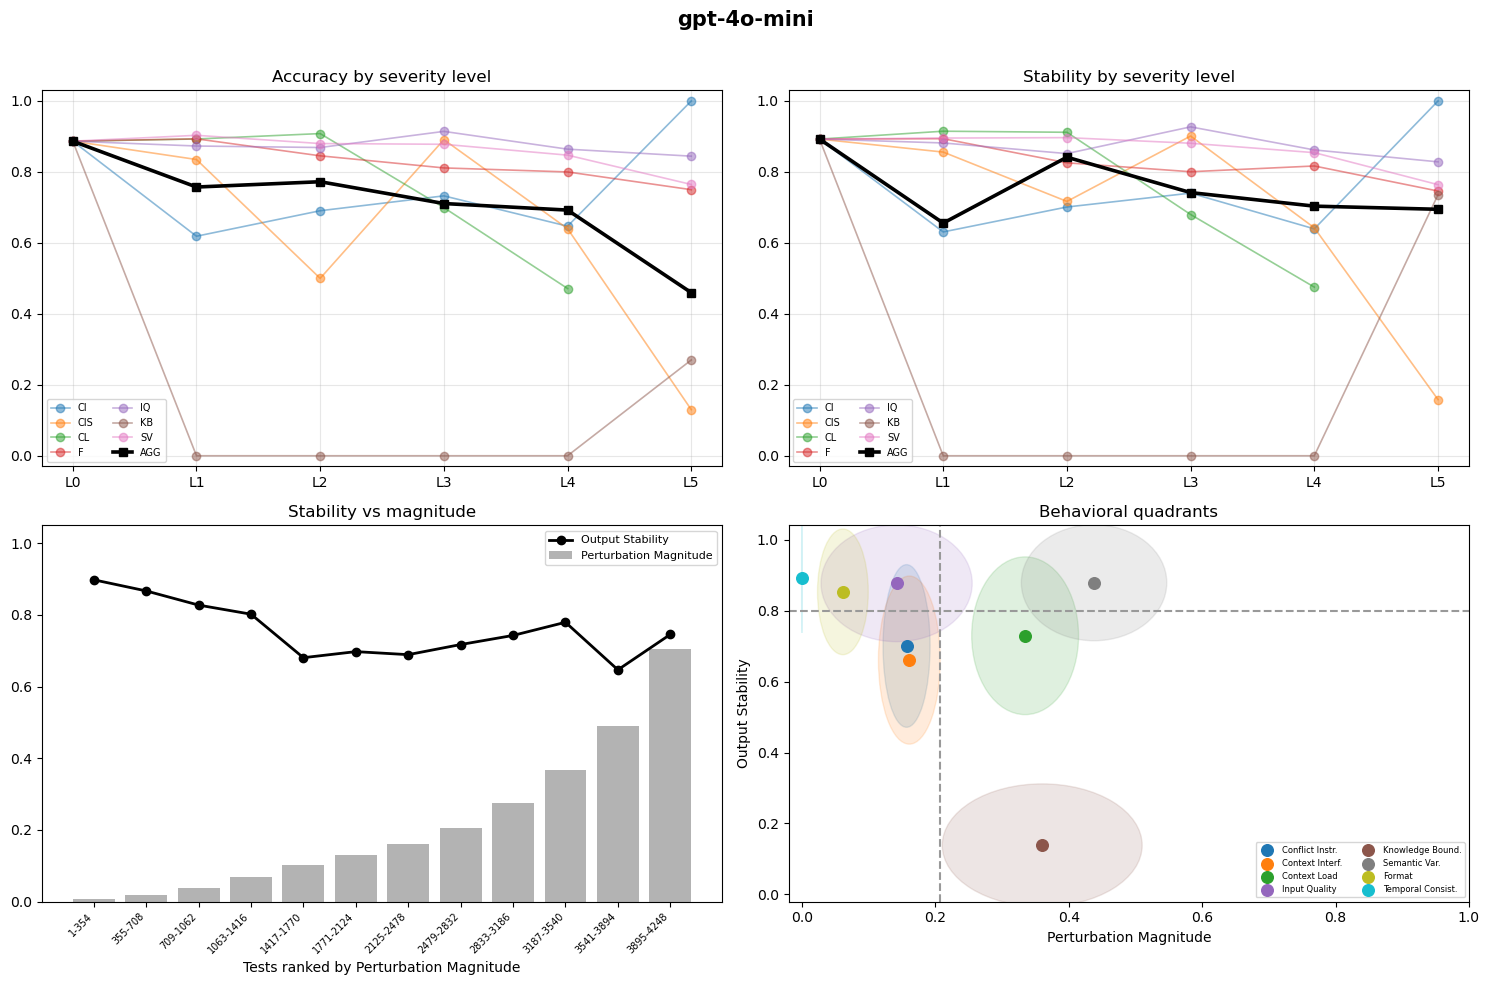

/var/folders/y_/x6jhv2rd5zvc9m7b7cmrl55m0000gn/T/ipykernel_77579/351648080.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  xthr=float(a['mx'].mean()); cmap=plt.cm.get_cmap('tab10',max(len(a),1))


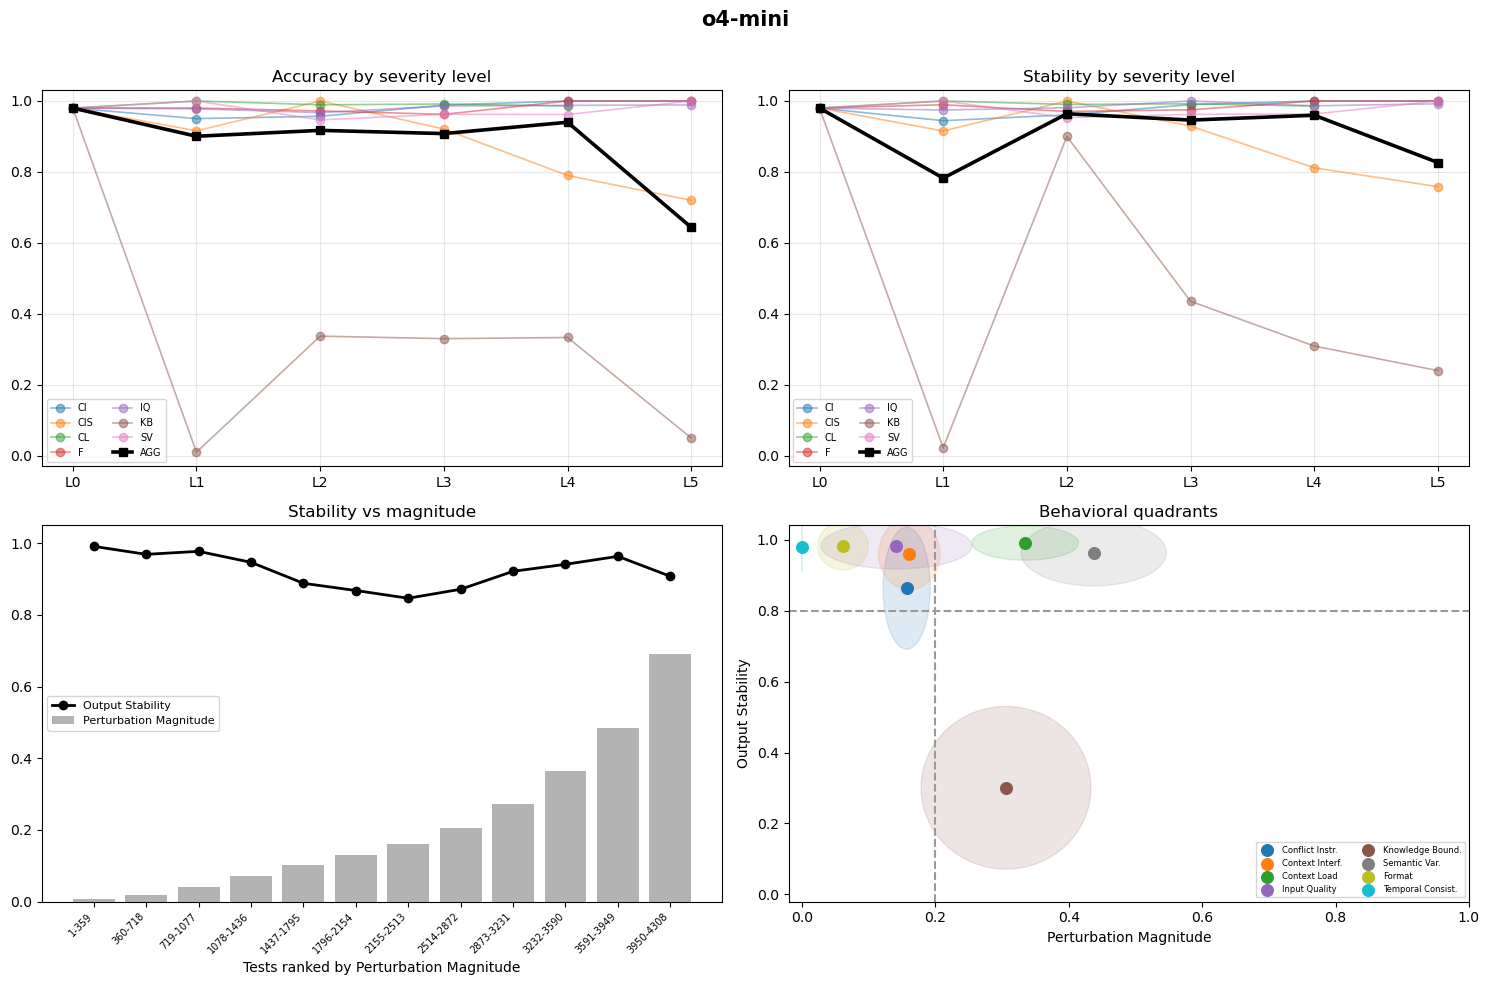

/var/folders/y_/x6jhv2rd5zvc9m7b7cmrl55m0000gn/T/ipykernel_77579/351648080.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  xthr=float(a['mx'].mean()); cmap=plt.cm.get_cmap('tab10',max(len(a),1))


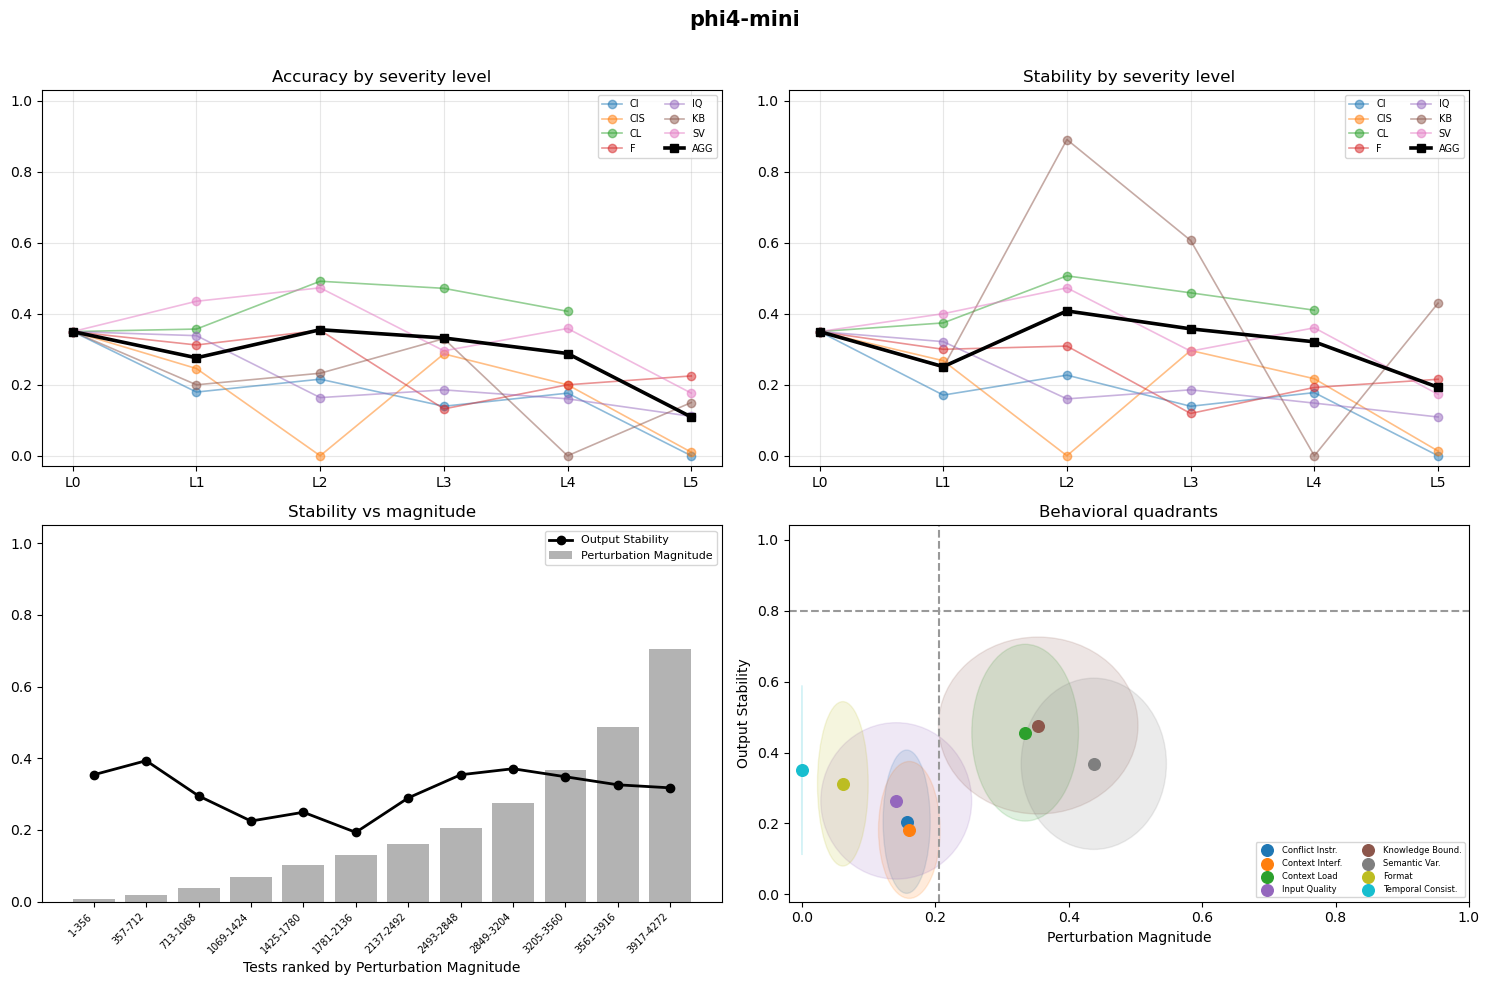

saved per-model 2x2 dashboards -> each run dir / fig_dashboard_2x2.png


In [18]:
# ===== Figure 5: per-model 2x2 dashboard (all four views in one figure) =====
def stab_fam_level(e):
    e=e.copy(); e['sim']=pd.to_numeric(e['Sim: outputs'],errors='coerce'); e['scr']=pd.to_numeric(e['Score'],errors='coerce')
    acc0=e[e['Category']=='Temporal Consistency']['sim'].mean(); st=e[e['fam'].notna()]; res={}
    for fam,g0 in st.groupby('fam'):
        row=[acc0]
        for L in LEVELS[1:]:
            g=g0[g0['Classified Level']==L]; s=g['sim']; w=g['scr']; m=s.notna()&w.notna()
            row.append((s[m]*w[m]).sum()/w[m].sum() if (m.any() and w[m].sum()>0) else (s[m].mean() if m.any() else np.nan))
        res[fam]=row
    return res

def dashboard(name, e):
    fig,axs=plt.subplots(2,2,figsize=(15,10)); fig.suptitle(name, fontsize=15, fontweight='bold')
    # (A) accuracy by level, per family + aggregate
    ax=axs[0,0]; acc0=e[e['Category']=='Temporal Consistency']['correct'].mean(); st=e[e['fam'].notna()]
    piv=st.pivot_table(index='fam',columns='Classified Level',values='correct',aggfunc='mean'); piv.insert(0,'L0',acc0)
    agg=[acc0]+[st[st['Classified Level']==L]['correct'].mean() for L in LEVELS[1:]]
    for fam,row in piv.iterrows(): ax.plot(LEVELS,[row.get(L,np.nan) for L in LEVELS],marker='o',alpha=0.5,lw=1.2,label=fam)
    ax.plot(LEVELS,agg,color='black',lw=2.6,marker='s',label='AGG')
    ax.set_title('Accuracy by severity level'); ax.set_ylim(-0.03,1.03); ax.grid(alpha=0.3); ax.legend(fontsize=7,ncol=2)
    # (B) stability by level, per family + aggregate
    ax=axs[0,1]; sf=stab_fam_level(e)
    for fam,row in sf.items(): ax.plot(LEVELS,row,marker='o',alpha=0.5,lw=1.2,label=fam)
    ax.plot(LEVELS,stability_curve(e),color='black',lw=2.6,marker='s',label='AGG')
    ax.set_title('Stability by severity level'); ax.set_ylim(-0.03,1.03); ax.grid(alpha=0.3); ax.legend(fontsize=7,ncol=2)
    # (C) stability vs magnitude (binned)
    ax=axs[1,0]; s=e[e['fam'].notna()].copy()
    s['sim']=pd.to_numeric(s['Sim: outputs'],errors='coerce'); s['scr']=pd.to_numeric(s['Score'],errors='coerce')
    s=s.dropna(subset=['sim','scr']).sort_values('scr').reset_index(drop=True); n=len(s); bs=max(1,n//12)
    xs=[]; mag=[]; ostab=[]
    for i in range(0,n,bs):
        ch=s.iloc[i:i+bs]
        if len(ch)<bs//3 and i>0: continue
        xs.append(f'{i+1}-{min(i+bs,n)}'); mag.append(ch['scr'].mean()); ostab.append(ch['sim'].mean())
    ax.bar(range(len(xs)),mag,color='0.7',label='Perturbation Magnitude')
    ax.plot(range(len(xs)),ostab,color='black',lw=2,marker='o',label='Output Stability')
    ax.set_xticks(range(len(xs))); ax.set_xticklabels(xs,rotation=45,ha='right',fontsize=7); ax.set_ylim(0,1.05)
    ax.set_xlabel('Tests ranked by Perturbation Magnitude'); ax.set_title('Stability vs magnitude'); ax.legend(fontsize=8)
    # (D) behavioral quadrant scatter
    ax=axs[1,1]; d=e.copy()
    if 'Gate' in d.columns: d=d[d['Gate']==True]
    if 'Test Type' in d.columns: d=d[d['Test Type']!='measurement']
    d['x']=pd.to_numeric(d['Score'],errors='coerce'); d['y']=pd.to_numeric(d['Sim: outputs'],errors='coerce'); d=d.dropna(subset=['x','y'])
    a=d.groupby('Category').agg(mx=('x','mean'),my=('y','mean'),sx=('x','std'),sy=('y','std')).fillna(0.0)
    xthr=float(a['mx'].mean()); cmap=plt.cm.get_cmap('tab10',max(len(a),1))
    for j,(c,row) in enumerate(a.iterrows()):
        col=cmap(j)
        ax.add_patch(Ellipse((row.mx,row.my),width=2*0.5*max(row.sx,1e-3),height=2*0.5*max(row.sy,1e-3),color=col,alpha=0.15))
        ax.scatter([row.mx],[row.my],color=col,s=70,zorder=3,label=SHORT.get(c,c))
    ax.axhline(THRESHOLD,ls='--',color='0.6'); ax.axvline(xthr,ls='--',color='0.6')
    ax.set_xlim(-0.02,1.0); ax.set_ylim(-0.02,1.04)
    ax.set_xlabel('Perturbation Magnitude'); ax.set_ylabel('Output Stability')
    ax.set_title('Behavioral quadrants'); ax.legend(fontsize=6,loc='lower right',ncol=2)
    fig.tight_layout(rect=[0,0,1,0.97])
    fig.savefig(RUNS/f'{name}__{DATASET}'/'fig_dashboard_2x2.png', dpi=120, bbox_inches='tight'); plt.show()

for name,e in models.items(): dashboard(name, e)
print('saved per-model 2x2 dashboards -> each run dir / fig_dashboard_2x2.png')

In [ ]:
# ===== 2x2: behavioral quadrant scatter for ALL models =====
import glob
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

RUNS=Path('output/runs')
DATASET='gsm8k_symbolic100'; THRESHOLD=0.80
SHORT={'Conflict Instruction Stress':'Conflict Instr.','Context Interference':'Context Interf.',
       'Context Load':'Context Load','Input Quality':'Input Quality','Knowledge Boundary':'Knowledge Bound.',
       'Semantic Variation':'Semantic Var.','Structural/Format':'Format','Temporal Consistency':'Temporal Consist.'}

# present the CoT run as phi4-mini, drop the direct-answer phi run
DROP=set(); RENAME={}
ORDER=['o4-mini','gemini-2.5-flash','gpt-4o-mini','phi4-mini']
models={}
for f in sorted(glob.glob(str(RUNS/f'*__{DATASET}'/'eval.csv'))):
    name=Path(f).parent.name.replace(f'__{DATASET}','')
    if name.startswith('_') or name in DROP: continue
    name=RENAME.get(name, name)
    models[name]=pd.read_csv(f)
names=[n for n in ORDER if n in models]+[n for n in models if n not in ORDER]

def quad_on_ax(ax, e, name, sigma=0.5):
    d=e.copy()
    if 'Gate' in d.columns: d=d[d['Gate']==True]
    if 'Test Type' in d.columns: d=d[d['Test Type']!='measurement']
    d['x']=pd.to_numeric(d['Score'],errors='coerce')
    d['y']=pd.to_numeric(d['Sim: outputs'],errors='coerce')   # Output Stability (continuous)
    d=d.dropna(subset=['x','y'])
    a=d.groupby('Category').agg(mx=('x','mean'),my=('y','mean'),sx=('x','std'),sy=('y','std')).fillna(0.0)
    xthr=float(a['mx'].mean()); cmap=plt.colormaps.get_cmap('tab10')
    for j,(c,row) in enumerate(a.iterrows()):
        col=cmap(j%10)
        ax.add_patch(Ellipse((row.mx,row.my), 2*sigma*max(row.sx,1e-3), 2*sigma*max(row.sy,1e-3), color=col, alpha=0.15, zorder=1))
        ax.scatter([row.mx],[row.my], color=col, s=70, zorder=3, label=SHORT.get(c,c))
        ax.annotate(SHORT.get(c,c), (row.mx,row.my), fontsize=7, color=col, ha='center', va='top', xytext=(0,-8), textcoords='offset points')
    ax.axhline(THRESHOLD, ls='--', color='0.6'); ax.axvline(xthr, ls='--', color='0.6')
    ax.set_xlim(-0.02,1.0); ax.set_ylim(-0.02,1.04)
    ax.text(xthr/2,(THRESHOLD+1.02)/2,'Stable',color='0.8',ha='center',fontsize=9)
    ax.text((xthr+1)/2,(THRESHOLD+1.02)/2,'Robust',color='0.8',ha='center',fontsize=9)
    ax.text(xthr/2,THRESHOLD/2,'Unstable',color='0.8',ha='center',fontsize=9)
    ax.text((xthr+1)/2,THRESHOLD/2,'Failure',color='0.8',ha='center',fontsize=9)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_ylabel('Output Stability', fontsize=11)

ncols=2; nrows=(len(names)+1)//2
fig,axs=plt.subplots(nrows, ncols, figsize=(8*ncols, 5.2*nrows)); axs=np.atleast_2d(axs)
for ax,name in zip(axs.flat, names): quad_on_ax(ax, models[name], name)
for ax in axs.flat[len(names):]: ax.axis('off')
for ax in axs[nrows-1,:]: ax.set_xlabel('Perturbation Magnitude', fontsize=11)
h,l=axs.flat[0].get_legend_handles_labels(); fig.legend(h, l, title='Category', loc='center right', fontsize=8)
fig.suptitle('Behavioral quadrants — all models', fontsize=15, fontweight='bold')
fig.tight_layout(rect=[0,0,0.87,0.97])
fig.savefig(RUNS/'fig_quadrant_all_models_2x2.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
# ===== Cross-model STABILITY table (per category) =====
import glob
from pathlib import Path
import pandas as pd, numpy as np

RUNS=Path('output/runs')
DATASET='gsm8k_symbolic100'; THRESHOLD=0.80
FAM=['Semantic Variation','Input Quality','Structural/Format','Context Interference',
     'Context Load','Conflict Instruction Stress','Knowledge Boundary']
DROP=set()                       # direct-answer phi: excluded
RENAME={}     # CoT run shown as phi4-mini
ORDER=['o4-mini','gemini-2.5-flash','gpt-4o-mini','phi4-mini']

def load(f):
    e=pd.read_csv(f)
    e['sim']=pd.to_numeric(e['Sim: outputs'],errors='coerce')
    e['scr']=pd.to_numeric(e['Score'],errors='coerce')
    return e

def wstab(s,w):                       # weighted stability = sum(sim*score)/sum(score)
    m=s.notna()&w.notna()
    return (s[m]*w[m]).sum()/w[m].sum() if (m.any() and w[m].sum()>0) else (s[m].mean() if m.any() else np.nan)

models={}
for f in sorted(glob.glob(str(RUNS/f'*__{DATASET}'/'eval.csv'))):
    n=Path(f).parent.name.replace(f'__{DATASET}','')
    if n.startswith('_') or n in DROP: continue
    models[RENAME.get(n,n)]=load(f)
cols=[m for m in ORDER if m in models]+[m for m in models if m not in ORDER]

cats=['Baseline']+FAM
tbl=pd.DataFrame(index=cats, columns=cols, dtype=float); tbl.index.name='Category'
for m in cols:
    e=models[m]; bl=e[e['Category']=='Temporal Consistency']
    tbl.loc['Baseline',m]=bl['sim'].mean()          # baseline stability = mean output similarity
    for c in FAM:
        g=e[e['Category']==c]
        tbl.loc[c,m]=wstab(g['sim'],g['scr']) if len(g) else np.nan

tbl=tbl.round(3)
tbl.to_csv(RUNS/'cross_model_stability_table.csv')
print('saved ->', RUNS/'cross_model_stability_table.csv')
tbl